# Project A3 “Motor imagery classification from EEG for brain computer interface”

## Introduction

Motor Imagery (MI) refers to the mental simulation of movement without any actual physical execution. EEG-based MI classification is a core component of Brain–Computer Interface (BCI) systems, enabling direct communication between the brain and external devices by decoding neural activity patterns associated with imagined movements.

In this notebook, we explore different end-to-end pipelines for **EEG Motor Imagery classification using Python**. The workflow includes EEG data loading, preprocessing, feature extraction, and supervised machine learning–based classification. 

## TO-DO LIST

- We need to add Data augmentation in the pipeline!
- Data preprocessing should be functional! (Now scattered across cells) minor rework
- Better Model checkpoints + save the best model (if val_loss < best_loss)
- Configuration management??? 
- Explicit data split function (split_subjects/cv) and explicit evaluation function... now data leakeage is possible (inline slicing...)
- Experiment runs tracking

In [64]:
import importlib
import warnings
import scipy.io
import os 
import utils.utils as u 
import utils.preprocessing as p 
import utils.models as m 
import numpy as np
import mne
import polars as pl
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
import random
import matplotlib.pyplot as plt
from mne.decoding import CSP
from itertools import groupby
from scipy.signal import butter, filtfilt

 
mne.set_log_level('WARNING')
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Reload modules to reflect recent changes:
importlib.reload(u)
importlib.reload(p)
importlib.reload(m)

config = {
    "seed": 42,
    "sampling_rate": 200,
    "window_size": 2.0,
    "batch_size": 64,
    "lr": 1e-3,
    "epochs": 50,
}

def set_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(config["seed"])

## 0. Data loading
We will start by loading the dataset. This dataset is divided in 3 different experiments:

- CLA -  Left and Right hand movement, or passive (3 classes)
- HaLT - Left and Right hand/leg, tongue and passive (6 classes)
- 5F -  Five fingers movement (more challenging) (5 classes)

The files are coming from MatLab, which makes them have some additional metadata that we will have to get rid of. Additionally, the file names give us some information about the patients. Since we are experimenting on the eeg signals alone, we will not use this information, even if it could potentially boost our results.

The dataset contains EEG recordings stored as a two-dimensional MATLAB array of size nS × 22, where each column represents a time series of voltage measurements from a single EEG channel. The recording includes 19 EEG leads arranged according to the international 10–20 system, two reference (ground) electrodes (A1 and A2), and one synchronization channel (X3 or X5). The synchronization channel does not contain physiological data and should be used solely to verify temporal alignment between the EEG data and the corresponding marker information.

Reference paper of the dataset: [Kaya18] Kaya, M., et al. A large electroencephalographic motor imagery
dataset for electroencephalographic brain computer interfaces, in Scientific
data, vol. 5, no. 1, pp. 1–16, 2018. 

https://www.researchgate.net/publication/328328921_A_large_electroencephalographic_motor_imagery_dataset_for_electroencephalographic_brain_computer_interfaces

All decisions taken in this notebook are based on different papers. The main paper that we follow as a general guideline is the following one:

[Altaheri23] H. Altaheri et al., Deep learning techniques for classification of
electroencephalogram (EEG) motor imagery (MI) signals: A review, Neural
Computing and Applications, vol. 35, no. 20, pp. 14681–14722, 2023

https://www.researchgate.net/publication/353327259_Deep_Learning_Techniques_for_Classification_of_Electroencephalogram_EEG_Motor_Imagery_MI_Signals_A_Review

This paper will be the backbone of our decisions regarding preprocessing, feature extraction and model selection. During the process we will refer to this paper often as [Altaheri23] and also refer to other papers that tackle specific problems.

 _NOTE: In the notebook some of the functions, that we though to be redundant are coming from additional python files, intending to make the code clearer and easier to follow. You can check this functions in the complementary python files if needed_

In [4]:
# Get the file names from directory of the files of the experiment
files=u.get_file_names("../data", experiment="CLA")
print(files)

['../data/CLA-SubjectA-160108-3St-LRHand.mat', '../data/CLA-SubjectB-151019-3St-LRHand.mat', '../data/CLA-SubjectB-151020-3St-LRHand.mat', '../data/CLA-SubjectB-151215-3St-LRHand.mat', '../data/CLA-SubjectC-151126-3St-LRHand.mat', '../data/CLA-SubjectC-151216-3St-LRHand.mat', '../data/CLA-SubjectC-151223-3St-LRHand.mat', '../data/CLA-SubjectD-151125-3St-LRHand.mat', '../data/CLA-SubjectE-151225-3St-LRHand.mat', '../data/CLA-SubjectE-160119-3St-LRHand.mat', '../data/CLA-SubjectE-160122-3St-LRHand.mat', '../data/CLA-SubjectF-150916-3St-LRHand.mat', '../data/CLA-SubjectF-150917-3St-LRHand.mat', '../data/CLA-SubjectF-150928-3St-LRHand.mat', '../data/CLA-SubjectJ-170504-3St-LRHand-Inter.mat', '../data/CLA-SubjectJ-170508-3St-LRHand-Inter.mat', '../data/CLA-SubjectJ-170510-3St-LRHand-Inter.mat']


In [5]:
def load_mat_file(FILE):
    """Load a .mat file and return its contents."""
    skip=False
    mat_data = scipy.io.loadmat(FILE)
    # The file includes metadata coming from python that we don't need.
    # We will focus on the 'o' key which contains the EEG data and information about the experiment.
    data = mat_data['o'][0, 0]       
    sfreq = int(data['sampFreq'][0, 0]) if data['sampFreq'].size > 0 else 200
    eeg_data = data['data'].T  # Shape: (n_channels, n_samples)
    channel_names = [
        str(ch[0]).strip("[]' ")
        for ch in data["chnames"]
    ]
    info = mne.create_info(
            ch_names=channel_names,
            sfreq=sfreq,
            ch_types='eeg'
        )
    if 'X5' in channel_names:
        info.set_channel_types({"X5": "misc"}) # Set 'X5' as misc type to avoid errors
    else: 
        print("Channel X5 not found, skipping file.")
        print(channel_names)
        skip=True
        return None, None, skip
    montage = mne.channels.make_standard_montage('standard_1020') # Set standard 10-20 montage
    info.set_montage(montage)
    raw = mne.io.RawArray(eeg_data, info)
    return raw, data, skip

## 0.1. Syncronization data exploration
First of all, as the dataset paper suggests, let's check if the syncronization is correct. First let's check if all the marker arrays are of the same length. As we will see, they are close but not perfect.

In [6]:
raw, data, _ = load_mat_file(files[0])
labels = np.array(data['marker'])
grouped_data = []
for k, g in groupby(labels):
    series_length = len(list(g))
    grouped_data.append((k, series_length))
for marker, length in grouped_data[:10]:
    if marker != 0:  # Only print non-zero markers
        print(f"Marker {marker}: Length {length}")
non_zero_lengths = [length for k, length in grouped_data if k != 0]
if non_zero_lengths:
    print(f"\nMinimum length of a non-zero marker series: {min(non_zero_lengths)}")
    


Marker [3]: Length 203
Marker [3]: Length 203
Marker [1]: Length 203
Marker [1]: Length 204
Marker [2]: Length 203

Minimum length of a non-zero marker series: 202


As seen the markers are not of the same length, which is suspicious. Let's check if the syncronization is correct.

Sync channel data (first 10 samples): [-0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]
Spike indixes:[1855 1856 1857 1858 1859 1860 1861 1862 3060 3061]
Compute gaps:[   1    1    1    1    1    1    1 1198    1    1]
Indices in gaps:[ 7 18 42 72 73 74 76 78 81 84]
Spike onsets in the plotted window: [100399 101084 101634]


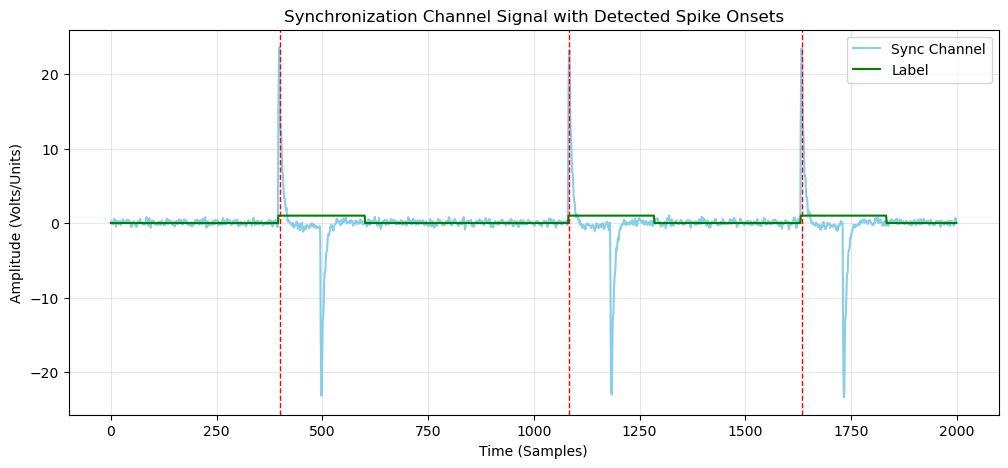

In [7]:
COLOR_MAP = {
    0: 'gray',    # Baseline/Rest
    1: 'blue',    # Mental Imagery 1
    2: 'red',     # Mental Imagery 2
    3: 'green',   # Mental Imagery 3 
}
THRESHOLD=20
sync_data = raw.get_data(picks='X5').flatten()
print(f"Sync channel data (first 10 samples): {sync_data[:10]}")
spikes=np.where(sync_data> 20)[0]
print(f"Spike indixes:{spikes[:10]}")
gaps = np.diff(spikes)
print(f"Compute gaps:{gaps[:10]}")

indices_in_gaps = np.where(gaps > 2)[0]
print(f"Indices in gaps:{indices_in_gaps[:10]}")
first_spike= spikes[0]
subsequent_spikes = spikes[indices_in_gaps]
final_spike_onsets = np.concatenate([[first_spike], subsequent_spikes])


START_OFFSET = 100000
WINDOW= 2000
plt.figure(figsize=(12, 5))
plt.plot(range(WINDOW), sync_data[START_OFFSET: START_OFFSET+WINDOW], label='Sync Channel', color='skyblue')
plt.plot(range(WINDOW), data["marker"][START_OFFSET: START_OFFSET+WINDOW], label='Label', color='green')

spikes_plot = final_spike_onsets[(final_spike_onsets >= START_OFFSET) & (final_spike_onsets < START_OFFSET + WINDOW)]
print(f"Spike onsets in the plotted window: {spikes_plot}")
for onset in spikes_plot:
    # Only label the first vertical line for a clean legend
    plt.axvline(x=onset-START_OFFSET, color='red', linestyle='--', linewidth=1)


plt.title('Synchronization Channel Signal with Detected Spike Onsets')
plt.xlabel('Time (Samples)')
plt.ylabel('Amplitude (Volts/Units)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



The syncronization seems to be right we just need to change the length of the windows to be consistent. We will do this later, since we will use a mne object called Epochs which will help us to cut our eeg data in even slices to classify. For this we will need to create an events object with the labels and the first marker index of each event. We will filter out the 0 label parts in this step too.

## 1. PREPROCESSING

First of all, as the dataset paper suggests, let's check if the syncronization is correct. First let's check if all the marker arrays are of the same length. As we will see, they are close but not perfect.

Quoting [Altaheri23]: "Pre-processing is generally performed in three main 
steps: channel selection, signal frequency filtering, and 
artifact removal."

One big candidate here is using the PREP pipeline, which was created as standarized preprocessing for EEG:

[ N. Bigdely-Shamlo, T. Mullen, C. Kothe, K. M. Su, and K. A. Robbins, \The prep pipeline: Standardized preprocessing for large-scale eeg analysis," Frontiers in Neuroinformatics, vol. 9, no. 16, 2015.]

https://www.frontiersin.org/journals/neuroinformatics/articles/10.3389/fninf.2015.00016/full

However our dataset does not seem a good candidate. Let's see why, going through the steps of the PREP pipeline
1. Line Noise Removal (Unwanted electrical interference from the power supply in the environment) 
 However or data has been already notched at 50Hz, so we can skip this step.  (From the paper: "These are the hardware filters and therefore part of all the published records. Additionally, a 50 Hz notch filter is present in the EEG-1200 hardware to reduce electrical grid interference.")\n
 A high-pass cutoff has been passed.

2. Robust Referencing 
 Robust referencing is essentialy a normalization, between the channels considered not bad. However, we will not do robust refencing. In the dataset paper technical validation section, which we closelly look since it is a similar experiment in the same data as ours, they followed the following pipeline and methodology:

[Mishchenko] Mishchenko, Y., Kaya, M., Ozbay, E. & Yanar, H. Developing a 3- to 6-state EEG-based brain-computer interface for a virtual
robotic manipulator control. IEEE Trans Biomed Eng. Epub ahead of print, https://doi.org/10.1109/TBME.2018.2865941
(2018).

https://www.researchgate.net/publication/319878377_Developing_a_3-_to_6-state_EEG-based_brain-computer_interface_for_a_robotic_manipulator_control

In this paper, after experimenting with several referencing systems, Laplace refencing is suggested as having the overall best performance. 

(3. Bad Channel Interpolation)

(4. Rereferencing or undo interpolation)


In [8]:
def PREP(raw):
    # --- High-pass cutoff ---
    raw.filter(l_freq=1.0, h_freq=None)
    # --- Laplace Reference (Surface Laplacian) ---
    # In MNE, this is often done by calculating the Surface Laplacian.
    raw_laplace = mne.preprocessing.compute_current_source_density(raw.copy().pick("eeg"))
    return raw_laplace

Here we create the Epochs object (splitting the data in equivalent length slices), the tmin and tmax have been chosen as [Mishchenko] and the technical validation suggest it as the best windowing: "As described in Results, the
decoding data frame choice of t1= 0sec and t2= 0.85sec
was found to offer the best overall performance for all subjects
and all mental imageries."

In [9]:
def create_epochs(raw_laplace, data):
    
    markers_diff = np.diff(data["marker"].squeeze())
    all_transition_indices = np.where(markers_diff != 0)[0] + 1
    all_values = data["marker"].squeeze()[all_transition_indices]
    valid_mask = (all_values != 0) & (all_values < 90)
    event_samples_filtered = all_transition_indices[valid_mask]
    event_values_filtered = all_values[valid_mask]
    
    # Reconstruct the events array
    event_count = len(event_samples_filtered)
    events = np.column_stack([
        event_samples_filtered, 
        np.zeros(event_count, dtype=int), 
        event_values_filtered
    ]).astype(int)
    
    epochs_laplace = mne.Epochs(
        raw=raw_laplace,
        events=events,
        tmin=0,
        tmax=0.85,
        baseline=None,
        preload=True
    )
    return epochs_laplace

In [10]:
all_X = []
all_y = []

for file in files:
    raw, data, skip = load_mat_file(file)
    if skip:
        continue
    raw_laplace = PREP(raw)
    epochs_laplace = create_epochs(raw_laplace, data)
    
    # Get the data and labels
    X_tmp = epochs_laplace.get_data()  # Shape: (n_epochs, n_channels, n_times)
    y_tmp = epochs_laplace.events[:, 2] # Shape: (n_epochs,)
    
    print(f"\n File: {file}")
    print(f"  X shape: {X_tmp.shape}")  
    print(f"  y shape: {y_tmp.shape}") 
    
    all_X.append(X_tmp)
    all_y.append(y_tmp)
    

# Combine everything into one big array
X = np.concatenate(all_X, axis=0)
y = np.concatenate(all_y, axis=0)

print(f"Final X shape: {X.shape}") # (Total_epochs, n_channels, n_times)
print(f"Final y shape: {y.shape}") # (Total_epochs,)


 File: ../data/CLA-SubjectA-160108-3St-LRHand.mat
  X shape: (960, 21, 171)
  y shape: (960,)

 File: ../data/CLA-SubjectB-151019-3St-LRHand.mat
  X shape: (959, 21, 171)
  y shape: (959,)

 File: ../data/CLA-SubjectB-151020-3St-LRHand.mat
  X shape: (959, 21, 171)
  y shape: (959,)

 File: ../data/CLA-SubjectB-151215-3St-LRHand.mat
  X shape: (960, 21, 171)
  y shape: (960,)

 File: ../data/CLA-SubjectC-151126-3St-LRHand.mat
  X shape: (960, 21, 171)
  y shape: (960,)

 File: ../data/CLA-SubjectC-151216-3St-LRHand.mat
  X shape: (960, 21, 171)
  y shape: (960,)

 File: ../data/CLA-SubjectC-151223-3St-LRHand.mat
  X shape: (959, 21, 171)
  y shape: (959,)

 File: ../data/CLA-SubjectD-151125-3St-LRHand.mat
  X shape: (958, 21, 171)
  y shape: (958,)

 File: ../data/CLA-SubjectE-151225-3St-LRHand.mat
  X shape: (959, 21, 171)
  y shape: (959,)

 File: ../data/CLA-SubjectE-160119-3St-LRHand.mat
  X shape: (958, 21, 171)
  y shape: (958,)

 File: ../data/CLA-SubjectE-160122-3St-LRHand.mat

Now let's do data augmentation. Data augmentation helps address overfitting by artificially increasing the diversity of the training data while preserving the underlying physiological characteristics of the signals. By introducing controlled variations models become more robust to inter-trial and inter-subject variability, ultimately improving classification performance and stability in EEG motor imagery tasks.

For data augmentation we will refer to one of the papers suggested by the teachers in the project presentation:

[Zhang21] C. Zhang, Y.-K. Kim, and A. Eskandarian, EEG-inception: an accurate and robust end-to-end 
neural network for EEG-based motor imagery classification, Journal of Neural Engineering, vol. 18, no. 
4, p. 046014, 2021.

https://www.researchgate.net/publication/348802845_EEG-Inception_An_Accurate_and_Robust_End-to-End_Neural_Network_for_EEG-based_Motor_Imagery_Classification

They used an 8th-order Butterworth high-pass filter with a cut-off frequency of 100 Hz (in our case 90Hz due to our low frequency rate) to first extract noise candidates. The extracted noise components are then subtracted from the original EEG signals and another random noise candidate is  added to the signal. This way by substracting and adding different noise, we can generate up to n-1 times more data. In our case we will just increasy times 3.

In [11]:
def augment_eeg_data(X, y, multiplier=3):
    if multiplier <= 1:
       return X, y 
    n_trials, n_chans, n_samples = X.shape
    
    # 1. Extract Noise (>90Hz) from all trials (We can't do 100Hz because original data is sampled at 200Hz)
    b, a = butter(8, 90, btype='high', fs=config["sampling_rate"])
    noise_candidates = filtfilt(b, a, X, axis=-1)
    
    # 2. Extract Clean Signals (<90Hz)
    clean_signals = X - noise_candidates
    
    X_aug_list = [X] # Start with original data
    y_aug_list = [y]
    
    for _ in range(multiplier - 1):
        # Create a randomized version of the dataset
        X_new = np.zeros_like(X)
        for i in range(n_trials):
            # Pick a random trial k to get noise from
            k = np.random.randint(0, n_trials)
            # S_aug = Clean_i + Noise_k
            X_new[i] = clean_signals[i] + noise_candidates[k]
        
        X_aug_list.append(X_new)
        y_aug_list.append(y)
        
    return np.concatenate(X_aug_list, axis=0), np.concatenate(y_aug_list, axis=0)

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

unique_labels = np.unique(y)
N = len(unique_labels)
print(f"Number of classes: {N}, Classes: {unique_labels}")

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=config["seed"], stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=config["seed"], stratify=y_temp)
X_train, y_train = augment_eeg_data(X_train, y_train, multiplier=1) #WE AUGMENT ONLY THE TRAINING SET

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y),
    y=y
)

# Convert to dict {class_index: weight}
class_weights = dict(enumerate(class_weights_array))
print(class_weights)

print(X_train.shape, X_val.shape, X_test.shape)


Number of classes: 3, Classes: [1 2 3]
{0: 0.9678489042675894, 1: 0.9678489042675894, 2: 1.071166427317696}
(9398, 21, 171) (2014, 21, 171) (2014, 21, 171)


## 2. FEATURE EXTRACTION and DATA PREPARATION
As summarized in [Altaheri23], EEG signals can be approched in 4 different ways:

1. Extracting features
2. Using spectral images
3. Directly using the raw preprocessed data
4. Using topological maps

For **1. Extracting features** we will follow the two main suggested approaches in [Altaheri23]: "Luo et al. utilized FBCSP to extract spatial-frequency sequential time slices from MI-EEG signals and classified them using long short-term memory (LSTM) and gated 
recurrent unit (GRU) models. The proposed method achieved good results for both recurrent models. In, the authors also used the FBCSP approach to extract spatial features from MI data and fed them into a CNN model as a 2D matrix."

Our approach is not exactly the same to the one found on the papers cited but it is inspired by them. It will be explained why and how later. The two papers are:

T. Luo and F. Chao, “Exploring spatial-frequency-sequential 
relationships for motor imagery classification with recurrent neural 
network,” BMC Bioinformatics, vol. 19, no. 1, p. 344, 2018. 

https://www.researchgate.net/publication/327967384_Exploring_spatial-frequency-sequential_relationships_for_motor_imagery_classification_with_recurrent_neural_network

B. E. Olivas-Padilla and M. I. Chacon-Murguia, “Classification of 
multiple motor imagery using deep convolutional neural networks 
and spatial filters,” Appl. Soft Comput., vol. 75, pp. 461–472, 2019. 

https://www.sciencedirect.com/science/article/pii/S156849461830663X?via%3Dihub

For **3. Directly using the raw preprocessed data** we will follow the two papers suggested by the teachers in the in the project presentation: the already referenced [Zhang21] and 

[Lawhern18] V. J. Lawhern, A. J. Solon, N. R. Waytowich, S. M. Gordon, C. P. Hung, and B. J. Lance, 
EEGNet: a compact convolutional neural network for EEG-based brain–computer interfaces, Journal of 
neural engineering, vol. 15, no. 5, p. 056013, 2018.

https://www.researchgate.net/publication/310953136_EEGNet_a_compact_convolutional_neural_network_for_EEG-based_brain-computer_interfaces

TODO: 2 or 4 or both or something else

In [14]:
def extract_windows(dataset, W, n_steps):
    projected = np.matmul(W, dataset.astype('float32'))
    n_samples = projected.shape[-1]
    win_len = int(n_samples * 0.5)
    starts = np.linspace(0, n_samples - win_len, n_steps).astype(int)
    windows = np.stack([projected[..., s:s+win_len] for s in starts], axis=2)
    log_var = np.log(np.var(windows, axis=-1) + 1e-10)
    return log_var

def process_band_to_matrix(X_train, y_train, X_val, X_test, sfreq):
    csp = CSP(n_components=4, reg='ledoit_wolf', log=True)
    csp.fit(X_train, y_train)
    W = csp.filters_ 
    train_cnn, train_rnn = extract_windows(X_train, W, 3), extract_windows(X_train, W, 15)
    val_cnn, val_rnn     = extract_windows(X_val, W, 3), extract_windows(X_val, W, 15)
    test_cnn, test_rnn   = extract_windows(X_test, W, 3), extract_windows(X_test, W, 15)

    return (train_cnn, val_cnn, test_cnn), (train_rnn, val_rnn, test_rnn)


In [15]:
from tqdm.auto import tqdm
if not os.path.exists('X_all_filtered.npy'):
    freq_bands = [[4, 8], [8, 12], [12, 16], [16, 20], [20, 24], [24, 28], [28, 32], [32,36], [36,40]]
    #1. Combine all data
    X_all = np.concatenate([X_train, X_val, X_test], axis=0)
    n_bands = len(freq_bands)
    X_all_filtered = np.zeros((n_bands, *X_all.shape), dtype='float32')
    for i, (l, h) in enumerate(tqdm(freq_bands, desc="Global Filtering")):
        # filter_data with copy=False is much faster
        X_all_filtered[i] = mne.filter.filter_data(
            X_all, 
            config["sampling_rate"], 
            l, h, 
            method='fir', 
            fir_design='firwin',
            n_jobs=-1,
            copy=False, 
            verbose=False
        ).astype('float32')

    # You access them via: X_all_filtered[band_idx, :split_val, :, :]

Global Filtering:   0%|          | 0/9 [00:00<?, ?it/s]

In [16]:
if not os.path.exists('X_all_filtered.npy'):
    np.save('X_all_filtered.npy', X_all_filtered)

In [17]:
if os.path.exists('X_all_filtered.npy'):
    X_all_filtered = np.load('X_all_filtered.npy').astype('float32')
    split_val = len(X_train)
    split_test = len(X_train) + len(X_val)
    train_bands = X_all_filtered[:, :split_val, :, :].astype('float32')
    test_bands = X_all_filtered[:, split_test:, :, :].astype('float32')
    val_bands = X_all_filtered[:, split_val:split_test, :, :].astype('float32')
    del X_all_filtered 
    import gc
    gc.collect()

In [18]:
results = []
for i in tqdm(range(len(train_bands)), desc="Processing CSP and Windows"):
    res = process_band_to_matrix(
        train_bands[i].astype('float32'), 
        y_train, 
        val_bands[i].astype('float32'), 
        test_bands[i].astype('float32'), 
        config["sampling_rate"]
    )
    results.append(res)
    
# Extract CNN data: index r[0] contains (train, val, test)
X_train_cnn = np.concatenate([r[0][0] for r in results], axis=1) # (Trials, 36, 3)
X_val_cnn   = np.concatenate([r[0][1] for r in results], axis=1)
X_test_cnn  = np.concatenate([r[0][2] for r in results], axis=1)

# Extract RNN data: index r[1] contains (train, val, test)
X_train_rnn = np.concatenate([r[1][0] for r in results], axis=1) # (Trials, 36, 15)
X_val_rnn   = np.concatenate([r[1][1] for r in results], axis=1)
X_test_rnn  = np.concatenate([r[1][2] for r in results], axis=1)

# Transpose RNN to (Trials, Time, Features) for LSTM/GRU
X_train_rnn = np.transpose(X_train_rnn, (0, 2, 1)) # (Trials, 15, 36)
X_val_rnn   = np.transpose(X_val_rnn, (0, 2, 1))
X_test_rnn  = np.transpose(X_test_rnn, (0, 2, 1))

print(f"CNN Shape: {X_train_cnn.shape}")
print(f"RNN Shape: {X_train_rnn.shape}")

Processing CSP and Windows:   0%|          | 0/9 [00:00<?, ?it/s]

CNN Shape: (9398, 189, 3)
RNN Shape: (9398, 15, 189)


In [19]:
from sklearn.preprocessing import StandardScaler
import numpy as np

n_train_cnn, height_cnn, width_cnn = X_train_cnn.shape
n_val_cnn = X_val_cnn.shape[0]
n_test_cnn = X_test_cnn.shape[0]

scaler_cnn = StandardScaler()

X_train_cnn_flat = X_train_cnn.reshape(n_train_cnn, -1)
X_train_cnn_scaled = scaler_cnn.fit_transform(X_train_cnn_flat)
X_val_cnn_flat = X_val_cnn.reshape(n_val_cnn, -1)
X_val_cnn_scaled = scaler_cnn.transform(X_val_cnn_flat)
X_test_cnn_flat = X_test_cnn.reshape(n_test_cnn, -1)
X_test_cnn_scaled = scaler_cnn.transform(X_test_cnn_flat)

n_train_rnn, n_steps_rnn, n_features_rnn = X_train_rnn.shape
n_val_rnn = X_val_rnn.shape[0]
n_test_rnn = X_test_rnn.shape[0]

scaler_rnn = StandardScaler()

X_train_rnn_flat = X_train_rnn.reshape(-1, n_features_rnn)
X_train_rnn_scaled = scaler_rnn.fit_transform(X_train_rnn_flat)
X_val_rnn_flat = X_val_rnn.reshape(-1, n_features_rnn)
X_val_rnn_scaled = scaler_rnn.transform(X_val_rnn_flat)
X_test_rnn_flat = X_test_rnn.reshape(-1, n_features_rnn)
X_test_rnn_scaled = scaler_rnn.transform(X_test_rnn_flat)

In [20]:
times = epochs_laplace.times
n_epochs, n_channels, n_times = X.shape
C = X.shape[1]
T = X.shape[2]
print(f"C: {C}, T: {T}, N: {N}")
print("#####################################################\n")


X_train = X_train[:, :, :, np.newaxis] 
X_test = X_test[:, :, :, np.newaxis]   
X_val = X_val[:, :, :, np.newaxis]  

X_train_features_cnn = X_train_cnn_scaled.reshape(n_train_cnn, height_cnn, width_cnn, 1)
X_val_features_cnn   = X_val_cnn_scaled.reshape(n_val_cnn, height_cnn, width_cnn, 1)
X_test_features_cnn  = X_test_cnn_scaled.reshape(n_test_cnn, height_cnn, width_cnn, 1)


X_train_features_rnn = X_train_rnn_scaled.reshape(n_train_rnn, n_steps_rnn, n_features_rnn)
X_val_features_rnn   = X_val_rnn_scaled.reshape(n_val_rnn, n_steps_rnn, n_features_rnn)
X_test_features_rnn   = X_test_rnn_scaled.reshape(n_test_rnn, n_steps_rnn, n_features_rnn)

label_map = {old: new for new, old in enumerate(unique_labels)}
print("Label map:", label_map)
y_train = np.array([label_map[int(l)] for l in y_train])
y_test = np.array([label_map[int(l)] for l in y_test])
y_val = np.array([label_map[int(l)] for l in y_val])
y_train = to_categorical(y_train, num_classes=N)
y_test = to_categorical(y_test, num_classes=N)
y_val = to_categorical(y_val, num_classes=N)

print("\n")
print("#####################################################\n")
print(f"X train shape: {X_train.shape}, X_train_features shape: {X_train_features_cnn.shape}, y train shape: {y_train.shape}")
print(f"X test shape: {X_test.shape}, X_test_features shape: {X_test_features_cnn.shape}, y test shape: {y_test.shape}")
print(f"X val shape: {X_val.shape}, X_val_features shape: {X_val_features_cnn.shape}, y val shape: {y_val.shape}")

C: 21, T: 171, N: 3
#####################################################

Label map: {1: 0, 2: 1, 3: 2}


#####################################################

X train shape: (9398, 21, 171, 1), X_train_features shape: (9398, 189, 3, 1), y train shape: (9398, 3)
X test shape: (2014, 21, 171, 1), X_test_features shape: (2014, 189, 3, 1), y test shape: (2014, 3)
X val shape: (2014, 21, 171, 1), X_val_features shape: (2014, 189, 3, 1), y val shape: (2014, 3)


In [21]:
import tensorflow as tf
epsilon = 1e-7 

def f1_score_metric(y_true, y_pred):
        
    # Calculate True Positives: (y_true * y_pred) clipped to [0, 1] and summed
    true_positives = tf.reduce_sum(tf.math.round(tf.clip_by_value(y_true * y_pred, 0, 1)))
    
    # Calculate Possible Positives (Actual Positives): Sum of true labels
    possible_positives = tf.reduce_sum(tf.math.round(tf.clip_by_value(y_true, 0, 1)))
    
    # Calculate Predicted Positives: Sum of predicted labels
    predicted_positives = tf.reduce_sum(tf.math.round(tf.clip_by_value(y_pred, 0, 1)))

    # 2. Calculate Precision and Recall
    precision = true_positives / (predicted_positives + epsilon)
    recall = true_positives / (possible_positives + epsilon)

    # 3. Calculate F1-Score (Harmonic Mean)
    f1_val = 2 * (precision * recall) / (precision + recall + epsilon)
    
    return f1_val

### Data Augmentation

TODO!!!!

Neural networks are extremely data hungry machine learning algorithms, specially attention based models for the complex patterns they are able to capture. We will make use of **Tensorflow dataset API** to add transformations, preprocessing, caching, shuffling, prefetching, batching...

There are 5 possible augmentations that can enhance data volume and help improve overall generalization of trained models. Without being destructive to the signal, we can add these generic signal augmentation techniques:

1) Gaussian Noise
2) Temporal Shift
3) Random Crop + Resize 
4) Channel Random Dropout  
5) Amplitude Scaling

In [ ]:
def gaussian_noise(x, std=0.01):
    noise = tf.random.normal(tf.shape(x), mean=0.0, stddev=std)
    return x + noise

def time_shift(x, max_shift=20):
    shift = tf.random.uniform([], -max_shift, max_shift, dtype=tf.int32)
    return tf.roll(x, shift=shift, axis=2)  # time axis

def random_crop_resize(x, crop_ratio=0.9):
    T = tf.shape(x)[2]
    crop_len = tf.cast(tf.cast(T, tf.float32) * crop_ratio, tf.int32)
    start = tf.random.uniform([], 0, T - crop_len, dtype=tf.int32)
    cropped = x[:, :, start:start+crop_len, :]
    return tf.image.resize(cropped, size=(x.shape[1], T))

def channel_dropout(x, drop_prob=0.1):
    mask = tf.cast(
        tf.random.uniform([tf.shape(x)[1], 1, 1]) > drop_prob,
        tf.float32,
    )
    return x * mask

def amplitude_scaling(x, scale_range=(0.8, 1.2)):
    scale = tf.random.uniform([], scale_range[0], scale_range[1])
    return x * scale


def eeg_augment(x):
    x = gaussian_noise(x, std=0.01)
    x = amplitude_scaling(x)
    x = time_shift(x, max_shift=15)
    x = random_crop_resize(x, crop_ratio=0.9)
    x = channel_dropout(x, drop_prob=0.1)
    return x

#train_ds = train_ds.map(
#    lambda x, y: (eeg_augment(x), y),
#    num_parallel_calls=tf.data.AUTOTUNE,
#)

In [ ]:
# TODO: This is a copy and paste of the lab TF dataset creation, it should  be adapted 
def create_dataset(reference_df, input_size, center_crop, batch_size, shuffle, cache_file=None):
    # Convert dataframe to lists
    file_names = list(reference_df.index)
    labels = reference_df['label']

    # Create a Dataset object
    dataset = tf.data.Dataset.from_tensor_slices((file_names, labels))

    # Map the load_and_preprocess_data function
    py_func = lambda file_name, label: (tf.numpy_function(load_and_preprocess_data, [file_name, data_dir], tf.float32), label)
    dataset = dataset.map(py_func)

    # Cache dataset
    if cache_file:
        dataset = dataset.cache(cache_file)

    # Shuffle (RANDOMNESS INTRODUCED, AVOID THE MODEL SEEING THE SAME CLASS AGAIN AND AGAIN)
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)


    # Repeat the dataset indefinitely (THE ORDER IS REALLY IMPORTANT, WE DONT WANT TO CROP INDEFINITELY!!!)
    dataset = dataset.repeat()

    # Map the crop function
    # Fixed the output_signature of tf.numpy_function to be tf.TensorShape([input_size]) instead of input_size
    py_func = lambda data, label: (tf.ensure_shape(tf.numpy_function(random_crop, [data, input_size, center_crop], tf.float32),
                                                   tf.TensorShape([input_size])), label)
    dataset = dataset.map(py_func)

    # Correct input shape for the network
    dataset = dataset.map(lambda data, label: (tf.expand_dims(data, axis=-1), label))

    # Batch (Transform the data into batches of data)
    dataset = dataset.batch(batch_size)

    # Prefetch (Parallelizes CPU and GPU so the GPU is training while the CPU is preparing the next batch of data through the dataset pipeline, then the GPU doesnt need to wait much)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


input_size = 4096
batch_size = 32

## 3. MODEL TRAINING

In this section we will proceed to train different implementations of neural network architectures to solve this non-trivial task. Given the format of the data shown below, CNN's or RNN's are often employed, however its important to note that due to the multi-channel nature of the data, RNN's alone won't work well.
 
Given the time-series nature of EEG data CNN's alone won't work to the fullest due to the local receptive field inductive bias, it won't be able to capture the long range dependencies in spite of multi-scale kernels as its commonly used in networks like InceptionV4.

So CNN + RNN has been shown in the literature to be better than the previous two alone, however BiLSTM/ LSTM / GRU... often fall short due to the vanishing gradients, serial training, parameter heavy layers, sensitive to sequence length... So often Attention is coupled with CNN's to overcome all this limitations (Parallelizable, Interpretable...), this gives birth to the **CONFORMER**.

Centralized Training configuration:

In [ ]:
config = {
    
}

###  Simple CNN (600K)

In [65]:
cnn=m.Simple_CNN(nb_classes=N, input_shape=(X_train_features_cnn.shape[1], X_train_features_cnn.shape[2], 1))
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[f1_score_metric]
)
cnn.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 189, 3, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 189, 3, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 189, 3, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 189, 3, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 189, 3, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 36288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │     4,644,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,664,579 (17.79 MB)

 Trainable params: 4,664,387 (17.79 MB)

 Non-trainable params: 192 (768.00 B)

In [66]:
# Callbacks
early_stop_eegnet = EarlyStopping(monitor='val_f1_score_metric', mode='max', patience=15, restore_best_weights=True)
checkpoint_eegnet = ModelCheckpoint("best_cnn.h5",monitor='val_f1_score_metric', mode='max', save_best_only=True)

history = cnn.fit(
    X_train_features_cnn, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val_features_cnn, y_val),
    shuffle=True,
    callbacks=[ checkpoint_eegnet, early_stop_eegnet],
    class_weight=class_weights
)

y_cnn = cnn.predict(X_test_features_cnn)
y_pred_cnn = np.argmax(y_cnn, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_cnn)
f1 = f1_score(y_true_labels, y_pred_cnn, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_cnn)
print(cm)

Epoch 1/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - f1_score_metric: 0.3719 - loss: 5.6982 

294/294 ━━━━━━━━━━━━━━━━━━━━ 36s 106ms/step - f1_score_metric: 0.3552 - loss: 2.9707 - val_f1_score_metric: 0.1663 - val_loss: 1.0752
Epoch 2/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - f1_score_metric: 0.3852 - loss: 1.2479

294/294 ━━━━━━━━━━━━━━━━━━━━ 33s 110ms/step - f1_score_metric: 0.3958 - loss: 1.2275 - val_f1_score_metric: 0.2883 - val_loss: 1.0347
Epoch 3/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - f1_score_metric: 0.4305 - loss: 1.1121

294/294 ━━━━━━━━━━━━━━━━━━━━ 35s 120ms/step - f1_score_metric: 0.4327 - loss: 1.0869 - val_f1_score_metric: 0.3480 - val_loss: 1.0232
Epoch 4/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - f1_score_metric: 0.4841 - loss: 0.9796

294/294 ━━━━━━━━━━━━━━━━━━━━ 35s 117ms/step - f1_score_metric: 0.4874 - loss: 0.9668 - val_f1_score_metric: 0.3606 - val_loss: 0.9951
Epoch 5/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - f1_score_metric: 0.5262 - loss: 0.8875

...

294/294 ━━━━━━━━━━━━━━━━━━━━ 49s 166ms/step - f1_score_metric: 0.8814 - loss: 0.2825 - val_f1_score_metric: 0.5020 - val_loss: 1.3749
Epoch 23/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - f1_score_metric: 0.8831 - loss: 0.2780

294/294 ━━━━━━━━━━━━━━━━━━━━ 52s 176ms/step - f1_score_metric: 0.8819 - loss: 0.2818 - val_f1_score_metric: 0.5069 - val_loss: 1.5656
Epoch 24/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 46s 156ms/step - f1_score_metric: 0.8885 - loss: 0.2628 - val_f1_score_metric: 0.5038 - val_loss: 1.5051
Epoch 25/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - f1_score_metric: 0.8902 - loss: 0.2620

294/294 ━━━━━━━━━━━━━━━━━━━━ 44s 149ms/step - f1_score_metric: 0.8910 - loss: 0.2606 - val_f1_score_metric: 0.5133 - val_loss: 1.7704
Epoch 26/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 49s 167ms/step - f1_score_metric: 0.8947 - loss: 0.2468 - val_f1_score_metric: 0.5096 - val_loss: 1.5486
Epoch 27/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 51s 172ms/step - f1_score_metric: 0.8974 - loss: 0.2469 - val_f1_score_metric: 0.5091 - val_loss: 1.7135
Epoch 28/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 43s 147ms/step - f1_score_metric: 0.9076 - loss: 0.2190 - val_f1_score_metric: 0.5121 - val_loss: 1.6590
Epoch 29/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 43s 147ms/step - f1_score_metric: 0.9077 - loss: 0.2164 - val_f1_score_metric: 0.5108 - val_loss: 1.6800
Epoch 30/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - f1_score_metric: 0.9041 - loss: 0.2331

294/294 ━━━━━━━━━━━━━━━━━━━━ 45s 153ms/step - f1_score_metric: 0.9104 - loss: 0.2184 - val_f1_score_metric: 0.5226 - val_loss: 1.8242
Epoch 31/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 44s 151ms/step - f1_score_metric: 0.9202 - loss: 0.1921 - val_f1_score_metric: 0.5111 - val_loss: 1.6581
Epoch 32/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 49s 166ms/step - f1_score_metric: 0.9167 - loss: 0.2048 - val_f1_score_metric: 0.5121 - val_loss: 1.6484
Epoch 33/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 49s 166ms/step - f1_score_metric: 0.9177 - loss: 0.1958 - val_f1_score_metric: 0.5073 - val_loss: 1.5423
Epoch 34/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 118s 400ms/step - f1_score_metric: 0.9265 - loss: 0.1760 - val_f1_score_metric: 0.5091 - val_loss: 1.7885
Epoch 35/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 96s 326ms/step - f1_score_metric: 0.9258 - loss: 0.1756 - val_f1_score_metric: 0.5090 - val_loss: 2.0109
Epoch 36/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 90s 306ms/step - f1_score_metric: 0.9311 - loss: 0.1738 - val_f1_score_metric: 0.5078 - 

KeyboardInterrupt: 

### LSTM Based (90K)

In [30]:
lstm=m.Simple_LSTM(nb_classes=N, input_shape=(X_train_features_rnn.shape[1], X_train_features_rnn.shape[2]))
lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[f1_score_metric]
)
lstm.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 15, 189)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 15, 189)        │           756 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 15, 64)         │        65,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 15, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 15, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 15, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 3)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,335 (348.96 KB)

 Trainable params: 88,701 (346.49 KB)

 Non-trainable params: 634 (2.48 KB)

In [31]:
# Callbacks
early_stop_eegnet = EarlyStopping(monitor='val_f1_score_metric', mode='max', patience=15, restore_best_weights=True)
checkpoint_eegnet = ModelCheckpoint("best_lstm.h5",monitor='val_f1_score_metric', mode='max', save_best_only=True)

history = lstm.fit(
    X_train_features_rnn, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val_features_rnn, y_val),
    shuffle=True,
    callbacks=[ checkpoint_eegnet, early_stop_eegnet],
    class_weight=class_weights
)

y_lstm = lstm.predict(X_test_features_rnn)
y_pred_lstm = np.argmax(y_lstm, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_lstm)
f1 = f1_score(y_true_labels, y_pred_lstm, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_lstm)
print(cm)

Epoch 1/100
293/294 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - f1_score_metric: 0.2825 - loss: 4.6424

294/294 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - f1_score_metric: 0.2566 - loss: 3.9331 - val_f1_score_metric: 0.0720 - val_loss: 2.7130
Epoch 2/100
293/294 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - f1_score_metric: 0.2597 - loss: 2.4255

294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - f1_score_metric: 0.2720 - loss: 2.1717 - val_f1_score_metric: 0.2182 - val_loss: 1.7592
Epoch 3/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - f1_score_metric: 0.3524 - loss: 1.6365

294/294 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - f1_score_metric: 0.3729 - loss: 1.5444 - val_f1_score_metric: 0.3590 - val_loss: 1.4120
Epoch 4/100
292/294 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - f1_score_metric: 0.4278 - loss: 1.3256

294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - f1_score_metric: 0.4426 - loss: 1.2906 - val_f1_score_metric: 0.3987 - val_loss: 1.2582
Epoch 5/100
293/294 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - f1_score_metric: 0.4605 - loss: 1.1863

...

294/294 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - f1_score_metric: 0.6000 - loss: 0.9956 - val_f1_score_metric: 0.4645 - val_loss: 1.2050
Epoch 15/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - f1_score_metric: 0.6115 - loss: 0.9910 - val_f1_score_metric: 0.4626 - val_loss: 1.2133
Epoch 16/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - f1_score_metric: 0.6193 - loss: 0.9851 - val_f1_score_metric: 0.4529 - val_loss: 1.2504
Epoch 17/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - f1_score_metric: 0.6272 - loss: 0.9806 - val_f1_score_metric: 0.4505 - val_loss: 1.2426
Epoch 18/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - f1_score_metric: 0.6363 - loss: 0.9750

294/294 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - f1_score_metric: 0.6472 - loss: 0.9685 - val_f1_score_metric: 0.4660 - val_loss: 1.2550
Epoch 19/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - f1_score_metric: 0.6480 - loss: 0.9676 - val_f1_score_metric: 0.4549 - val_loss: 1.2606
Epoch 20/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - f1_score_metric: 0.6537 - loss: 0.9615 - val_f1_score_metric: 0.4397 - val_loss: 1.2763
Epoch 21/100
292/294 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - f1_score_metric: 0.6571 - loss: 0.9584

294/294 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - f1_score_metric: 0.6703 - loss: 0.9504 - val_f1_score_metric: 0.4711 - val_loss: 1.2850
Epoch 22/100
293/294 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - f1_score_metric: 0.6688 - loss: 0.9427

294/294 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - f1_score_metric: 0.6750 - loss: 0.9442 - val_f1_score_metric: 0.4797 - val_loss: 1.3232
Epoch 23/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - f1_score_metric: 0.6810 - loss: 0.9377 - val_f1_score_metric: 0.4703 - val_loss: 1.3267
Epoch 24/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - f1_score_metric: 0.6939 - loss: 0.9337 - val_f1_score_metric: 0.4775 - val_loss: 1.3614
Epoch 25/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - f1_score_metric: 0.7082 - loss: 0.9188 - val_f1_score_metric: 0.4683 - val_loss: 1.3549
Epoch 26/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - f1_score_metric: 0.7150 - loss: 0.9078 - val_f1_score_metric: 0.4679 - val_loss: 1.4451
Epoch 27/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - f1_score_metric: 0.7287 - loss: 0.9009 - val_f1_score_metric: 0.4579 - val_loss: 1.4179
Epoch 28/100
293/294 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - f1_score_metric: 0.7131 - loss: 0.9149

294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - f1_score_metric: 0.7254 - loss: 0.9015 - val_f1_score_metric: 0.4896 - val_loss: 1.4847
Epoch 29/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - f1_score_metric: 0.7269 - loss: 0.9075 - val_f1_score_metric: 0.4800 - val_loss: 1.4942
Epoch 30/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - f1_score_metric: 0.7386 - loss: 0.8855 - val_f1_score_metric: 0.4767 - val_loss: 1.5208
Epoch 31/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - f1_score_metric: 0.7518 - loss: 0.8698 - val_f1_score_metric: 0.4777 - val_loss: 1.6044
Epoch 32/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - f1_score_metric: 0.7588 - loss: 0.8631 - val_f1_score_metric: 0.4707 - val_loss: 1.5216
Epoch 33/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - f1_score_metric: 0.7569 - loss: 0.8755 - val_f1_score_metric: 0.4614 - val_loss: 1.5153
Epoch 34/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - f1_score_metric: 0.7560 - loss: 0.8661 - val_f1_score_metric: 0.4701 - val_loss: 1.558

### GRU Based (132K)

In [32]:
gru=m.Simple_GRU(nb_classes=N, input_shape=(X_train_features_rnn.shape[1], X_train_features_rnn.shape[2]))
gru.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[f1_score_metric]
)
gru.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 15, 189)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 15, 189)        │           756 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │       122,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           195 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 3)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,215 (516.46 KB)

 Trainable params: 131,581 (513.99 KB)

 Non-trainable params: 634 (2.48 KB)

In [33]:
# Callbacks
early_stop_eegnet = EarlyStopping(monitor='val_f1_score_metric', mode='max', patience=15, restore_best_weights=True)
checkpoint_eegnet = ModelCheckpoint("best_gru.h5",monitor='val_f1_score_metric', mode='max', save_best_only=True)

history = gru.fit(
    X_train_features_rnn, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val_features_rnn, y_val),
    shuffle=True,
    callbacks=[ checkpoint_eegnet, early_stop_eegnet],
    class_weight=class_weights
)

y_gru = gru.predict(X_test_features_rnn)
y_pred_gru = np.argmax(y_gru, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_gru)
f1 = f1_score(y_true_labels, y_pred_gru, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_gru)
print(cm)

Epoch 1/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - f1_score_metric: 0.3409 - loss: 3.7502

294/294 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - f1_score_metric: 0.3444 - loss: 2.9860 - val_f1_score_metric: 0.2521 - val_loss: 2.0906
Epoch 2/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - f1_score_metric: 0.3476 - loss: 1.9546

294/294 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - f1_score_metric: 0.3638 - loss: 1.8239 - val_f1_score_metric: 0.2852 - val_loss: 1.6049
Epoch 3/100
292/294 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - f1_score_metric: 0.3794 - loss: 1.4885

294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - f1_score_metric: 0.3914 - loss: 1.4199 - val_f1_score_metric: 0.3227 - val_loss: 1.3356
Epoch 4/100
292/294 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - f1_score_metric: 0.4032 - loss: 1.2425

294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - f1_score_metric: 0.4112 - loss: 1.2085 - val_f1_score_metric: 0.3621 - val_loss: 1.1855
Epoch 5/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - f1_score_metric: 0.4159 - loss: 1.1189

...

294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - f1_score_metric: 0.6356 - loss: 0.9324 - val_f1_score_metric: 0.4544 - val_loss: 1.2337
Epoch 21/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - f1_score_metric: 0.6473 - loss: 0.9323 - val_f1_score_metric: 0.4445 - val_loss: 1.2418
Epoch 22/100
292/294 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - f1_score_metric: 0.6580 - loss: 0.9251

294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - f1_score_metric: 0.6654 - loss: 0.9172 - val_f1_score_metric: 0.4650 - val_loss: 1.2862
Epoch 23/100
293/294 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - f1_score_metric: 0.6751 - loss: 0.9097

294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - f1_score_metric: 0.6784 - loss: 0.9098 - val_f1_score_metric: 0.4705 - val_loss: 1.3088
Epoch 24/100
292/294 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - f1_score_metric: 0.6845 - loss: 0.9053

294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - f1_score_metric: 0.6915 - loss: 0.9020 - val_f1_score_metric: 0.4783 - val_loss: 1.3370
Epoch 25/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - f1_score_metric: 0.6994 - loss: 0.8976 - val_f1_score_metric: 0.4613 - val_loss: 1.4163
Epoch 26/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - f1_score_metric: 0.7057 - loss: 0.8986 - val_f1_score_metric: 0.4741 - val_loss: 1.4370
Epoch 27/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - f1_score_metric: 0.7176 - loss: 0.8866 - val_f1_score_metric: 0.4659 - val_loss: 1.4060
Epoch 28/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - f1_score_metric: 0.7288 - loss: 0.8731 - val_f1_score_metric: 0.4710 - val_loss: 1.4962
Epoch 29/100
292/294 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - f1_score_metric: 0.7353 - loss: 0.8879

294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - f1_score_metric: 0.7462 - loss: 0.8647 - val_f1_score_metric: 0.4863 - val_loss: 1.5124
Epoch 30/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - f1_score_metric: 0.7504 - loss: 0.8592 - val_f1_score_metric: 0.4723 - val_loss: 1.5926
Epoch 31/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - f1_score_metric: 0.7609 - loss: 0.8458 - val_f1_score_metric: 0.4671 - val_loss: 1.6144
Epoch 32/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - f1_score_metric: 0.7680 - loss: 0.8458 - val_f1_score_metric: 0.4555 - val_loss: 1.6560
Epoch 33/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - f1_score_metric: 0.7765 - loss: 0.8410 - val_f1_score_metric: 0.4812 - val_loss: 1.6762
Epoch 34/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - f1_score_metric: 0.7934 - loss: 0.8079 - val_f1_score_metric: 0.4707 - val_loss: 1.8263
Epoch 35/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - f1_score_metric: 0.7898 - loss: 0.8182 - val_f1_score_metric: 0.4705 - val_loss: 1.819

### Shallow ConvNet (36K)

"RAW SIGNAL" MODELS - COVOLUTIONAL MODELS

In [34]:
shallow=m.ShallowConvNet(nb_classes=N, Chans = C, Samples =T , dropoutRate = 0.5)
shallow.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[f1_score_metric]
)
shallow.summary()

C:\Users\josub\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 21, 171, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 21, 159, 40)    │           560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 1, 159, 40)     │        33,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 1, 159, 40)     │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 1, 159, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 1, 18, 40)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 1, 18, 40)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1, 18, 40)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 720)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 3)              │         2,163 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 3)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,483 (142.51 KB)

 Trainable params: 36,403 (142.20 KB)

 Non-trainable params: 80 (320.00 B)

In [35]:
# Callbacks
early_stop_shallow = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
checkpoint_shallow = ModelCheckpoint("best_shallow.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

history =shallow.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[early_stop_shallow, checkpoint_shallow],
    class_weight=class_weights
)

y_shallow = shallow.predict(X_test)
y_pred_shallow = np.argmax(y_shallow, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_shallow)
f1 = f1_score(y_true_labels, y_pred_shallow, average='weighted')
print(f"\nModel Accurºacy on Test Set: {accuracy * 100:.2f}%")
print(f"Model F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_shallow)
print(cm)

Epoch 1/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - f1_score_metric: 0.3088 - loss: 1.2463

294/294 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - f1_score_metric: 0.3717 - loss: 1.0934 - val_f1_score_metric: 0.5640 - val_loss: 0.8422
Epoch 2/100
293/294 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - f1_score_metric: 0.5685 - loss: 0.8673

294/294 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - f1_score_metric: 0.5915 - loss: 0.8396 - val_f1_score_metric: 0.6541 - val_loss: 0.7349
Epoch 3/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - f1_score_metric: 0.6540 - loss: 0.7584

294/294 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - f1_score_metric: 0.6627 - loss: 0.7403 - val_f1_score_metric: 0.6798 - val_loss: 0.6855
Epoch 4/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - f1_score_metric: 0.6852 - loss: 0.7060

294/294 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - f1_score_metric: 0.6917 - loss: 0.6960 - val_f1_score_metric: 0.6988 - val_loss: 0.6802
Epoch 5/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - f1_score_metric: 0.7134 - loss: 0.6516

...

294/294 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - f1_score_metric: 0.7608 - loss: 0.5616 - val_f1_score_metric: 0.7432 - val_loss: 0.6100
Epoch 15/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - f1_score_metric: 0.7664 - loss: 0.5587 - val_f1_score_metric: 0.7279 - val_loss: 0.6184
Epoch 16/100
293/294 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - f1_score_metric: 0.7654 - loss: 0.5634

294/294 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - f1_score_metric: 0.7655 - loss: 0.5599 - val_f1_score_metric: 0.7441 - val_loss: 0.6043
Epoch 17/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - f1_score_metric: 0.7638 - loss: 0.5553 - val_f1_score_metric: 0.7330 - val_loss: 0.6155
Epoch 18/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - f1_score_metric: 0.7692 - loss: 0.5566 - val_f1_score_metric: 0.7309 - val_loss: 0.6137
Epoch 19/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - f1_score_metric: 0.7653 - loss: 0.5556 - val_f1_score_metric: 0.7288 - val_loss: 0.6219
Epoch 20/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - f1_score_metric: 0.7733 - loss: 0.5435 - val_f1_score_metric: 0.7276 - val_loss: 0.6289
Epoch 21/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - f1_score_metric: 0.7680 - loss: 0.5528 - val_f1_score_metric: 0.7378 - val_loss: 0.6158
Epoch 22/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - f1_score_metric: 0.7678 - loss: 0.5541 - val_f1_score_metric: 0.7429 - val_loss

294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - f1_score_metric: 0.7742 - loss: 0.5476 - val_f1_score_metric: 0.7455 - val_loss: 0.5922
Epoch 30/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - f1_score_metric: 0.7803 - loss: 0.5362 - val_f1_score_metric: 0.7363 - val_loss: 0.6049
Epoch 31/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - f1_score_metric: 0.7766 - loss: 0.5385 - val_f1_score_metric: 0.7327 - val_loss: 0.6102
Epoch 32/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - f1_score_metric: 0.7762 - loss: 0.5394 - val_f1_score_metric: 0.7348 - val_loss: 0.6040
Epoch 33/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - f1_score_metric: 0.7799 - loss: 0.5356 - val_f1_score_metric: 0.7311 - val_loss: 0.6074
Epoch 34/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - f1_score_metric: 0.7801 - loss: 0.5366 - val_f1_score_metric: 0.7383 - val_loss: 0.6061
Epoch 35/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - f1_score_metric: 0.7773 - loss: 0.5359 - val_f1_score_metric: 0.7440 - val_loss

294/294 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - f1_score_metric: 0.7814 - loss: 0.5293 - val_f1_score_metric: 0.7467 - val_loss: 0.5881
Epoch 43/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - f1_score_metric: 0.7800 - loss: 0.5295 - val_f1_score_metric: 0.7403 - val_loss: 0.5987
Epoch 44/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - f1_score_metric: 0.7821 - loss: 0.5304 - val_f1_score_metric: 0.7400 - val_loss: 0.5959
Epoch 45/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - f1_score_metric: 0.7805 - loss: 0.5279 - val_f1_score_metric: 0.7309 - val_loss: 0.5976
Epoch 46/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - f1_score_metric: 0.7822 - loss: 0.5278 - val_f1_score_metric: 0.7395 - val_loss: 0.5917
Epoch 47/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - f1_score_metric: 0.7826 - loss: 0.5266 - val_f1_score_metric: 0.7352 - val_loss: 0.5996
Epoch 48/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - f1_score_metric: 0.7810 - loss: 0.5272 - val_f1_score_metric: 0.7305 - val_loss

294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - f1_score_metric: 0.7805 - loss: 0.5285 - val_f1_score_metric: 0.7549 - val_loss: 0.5768
Epoch 54/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - f1_score_metric: 0.7849 - loss: 0.5253 - val_f1_score_metric: 0.7303 - val_loss: 0.6025
Epoch 55/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 13s 45ms/step - f1_score_metric: 0.7850 - loss: 0.5249 - val_f1_score_metric: 0.7489 - val_loss: 0.5920
Epoch 56/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - f1_score_metric: 0.7846 - loss: 0.5262 - val_f1_score_metric: 0.7448 - val_loss: 0.5871
Epoch 57/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - f1_score_metric: 0.7798 - loss: 0.5310 - val_f1_score_metric: 0.7459 - val_loss: 0.5821
Epoch 58/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - f1_score_metric: 0.7846 - loss: 0.5291 - val_f1_score_metric: 0.7421 - val_loss: 0.6025
Epoch 59/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - f1_score_metric: 0.7855 - loss: 0.5257 - val_f1_score_metric: 0.7514 - val_loss

### EEGNet (2018) (1.8K?)

In [36]:
eegnet = m.EEGNet(nb_classes=N,Chans = C, Samples =T ,  dropoutRate = 0.5)
eegnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[f1_score_metric]
)
eegnet.summary()


C:\Users\josub\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 21, 171, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 21, 171, 8)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 21, 171, 8)     │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 1, 171, 16)     │           336 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 1, 171, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 1, 171, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 1, 42, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1, 42, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 1, 42, 16)      │           512 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 1, 42, 16)      │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 1, 42, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 1, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           243 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Activation)            │ (None, 3)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,763 (6.89 KB)

 Trainable params: 1,683 (6.57 KB)

 Non-trainable params: 80 (320.00 B)

In [37]:
# Callbacks
early_stop_eegnet = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
checkpoint_eegnet = ModelCheckpoint("best_eegnet.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

history =eegnet.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[ checkpoint_eegnet, early_stop_eegnet],
    class_weight=class_weights
)

y_eegnet = eegnet.predict(X_test)
y_pred_eegnet = np.argmax(y_eegnet, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_eegnet)
f1 = f1_score(y_true_labels, y_pred_eegnet, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_eegnet)
print(cm)

Epoch 1/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - f1_score_metric: 0.1121 - loss: 1.0502

294/294 ━━━━━━━━━━━━━━━━━━━━ 24s 53ms/step - f1_score_metric: 0.2482 - loss: 0.9917 - val_f1_score_metric: 0.4092 - val_loss: 0.8968
Epoch 2/100
293/294 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - f1_score_metric: 0.4781 - loss: 0.8906

294/294 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step - f1_score_metric: 0.4953 - loss: 0.8797 - val_f1_score_metric: 0.5647 - val_loss: 0.8229
Epoch 3/100
293/294 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - f1_score_metric: 0.5370 - loss: 0.8506

294/294 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - f1_score_metric: 0.5435 - loss: 0.8469 - val_f1_score_metric: 0.5993 - val_loss: 0.7961
Epoch 4/100
293/294 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - f1_score_metric: 0.5667 - loss: 0.8304

294/294 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step - f1_score_metric: 0.5683 - loss: 0.8291 - val_f1_score_metric: 0.6077 - val_loss: 0.7855
Epoch 5/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - f1_score_metric: 0.5818 - loss: 0.8155

...

294/294 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - f1_score_metric: 0.6710 - loss: 0.7239 - val_f1_score_metric: 0.6971 - val_loss: 0.6878
Epoch 68/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step - f1_score_metric: 0.6702 - loss: 0.7246 - val_f1_score_metric: 0.6957 - val_loss: 0.6901
Epoch 69/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - f1_score_metric: 0.6790 - loss: 0.7152

294/294 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - f1_score_metric: 0.6724 - loss: 0.7232 - val_f1_score_metric: 0.6985 - val_loss: 0.6786
Epoch 70/100
293/294 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - f1_score_metric: 0.6723 - loss: 0.7202

294/294 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step - f1_score_metric: 0.6742 - loss: 0.7184 - val_f1_score_metric: 0.7008 - val_loss: 0.6827
Epoch 71/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step - f1_score_metric: 0.6714 - loss: 0.7268 - val_f1_score_metric: 0.6980 - val_loss: 0.6838
Epoch 72/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - f1_score_metric: 0.6744 - loss: 0.7205 - val_f1_score_metric: 0.6938 - val_loss: 0.6826
Epoch 73/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - f1_score_metric: 0.6713 - loss: 0.7246 - val_f1_score_metric: 0.6978 - val_loss: 0.6792
Epoch 74/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - f1_score_metric: 0.6708 - loss: 0.7253 - val_f1_score_metric: 0.6969 - val_loss: 0.6873
Epoch 75/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - f1_score_metric: 0.6779 - loss: 0.7211 - val_f1_score_metric: 0.6859 - val_loss: 0.6929
Epoch 76/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - f1_score_metric: 0.6782 - loss: 0.7169 - val_f1_score_metric: 0.6970 - val_loss

294/294 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - f1_score_metric: 0.6741 - loss: 0.7209 - val_f1_score_metric: 0.7015 - val_loss: 0.6783
Epoch 81/100
293/294 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - f1_score_metric: 0.6621 - loss: 0.7193

294/294 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - f1_score_metric: 0.6714 - loss: 0.7216 - val_f1_score_metric: 0.7036 - val_loss: 0.6776
Epoch 82/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - f1_score_metric: 0.6716 - loss: 0.7240 - val_f1_score_metric: 0.6964 - val_loss: 0.6855
Epoch 83/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - f1_score_metric: 0.6754 - loss: 0.7213 - val_f1_score_metric: 0.6928 - val_loss: 0.6803
Epoch 84/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - f1_score_metric: 0.6715 - loss: 0.7266 - val_f1_score_metric: 0.7017 - val_loss: 0.6779
Epoch 85/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - f1_score_metric: 0.6754 - loss: 0.7227 - val_f1_score_metric: 0.7011 - val_loss: 0.6780
Epoch 86/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - f1_score_metric: 0.6711 - loss: 0.7195 - val_f1_score_metric: 0.6977 - val_loss: 0.6762
Epoch 87/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - f1_score_metric: 0.6776 - loss: 0.7176 - val_f1_score_metric: 0.6999 - val_loss

### Inception V4 (281K)

In [38]:
inception = m.Inception(nb_classes=N,Chans = C, Samples =T )
inception.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[ f1_score_metric]
)
inception.summary()


(None, 21, 171)


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 21, 171)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 21, 9)     │      1,548 │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 21, 171)   │          0 │ input_layer_8[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 21, 9)     │      1,629 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 21, 9)     │      4,869 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 21, 9)     │      8,109 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 21, 9)     │     12,159 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 21, 9)     │     16,209 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 21, 9)     │      1,548 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 21, 54)    │          0 │ conv1d_1[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_2[0][0],   │
│                     │                   │            │ conv1d_3[0][0],   │
│                     │                   │            │ conv1d_4[0][0],   │
│                     │                   │            │ conv1d_5[0][0],   │
│                     │                   │            │ conv1d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 21, 54)    │        216 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 21, 54)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 21, 9)     │        495 │ activation_11[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 21, 54)    │          0 │ activation_11[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 21, 9)     │      1,629 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 21, 9)     │      4,869 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 21, 9)     │      8,109 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 21, 9)     │     12,159 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 21, 9)     │     16,209 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 21, 9)     │        495 │ max_pooling1d_1[

 Total params: 281,073 (1.07 MB)

 Trainable params: 280,425 (1.07 MB)

 Non-trainable params: 648 (2.53 KB)

In [39]:
# Callbacks
early_stop_inception = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
checkpoint_inception = ModelCheckpoint("best_inception.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

history = inception.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[ checkpoint_inception, early_stop_inception],
    class_weight=class_weights
)

y_inception = inception.predict(X_test)
y_pred_inception = np.argmax(y_inception, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_inception)
f1 = f1_score(y_true_labels, y_pred_inception, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_inception)
print(cm)


Epoch 1/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - f1_score_metric: 0.3992 - loss: 1259.9859

294/294 ━━━━━━━━━━━━━━━━━━━━ 48s 75ms/step - f1_score_metric: 0.4231 - loss: 763.6499 - val_f1_score_metric: 0.4597 - val_loss: 299.6527
Epoch 2/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - f1_score_metric: 0.4472 - loss: 252.8099 - val_f1_score_metric: 0.4378 - val_loss: 231.5010
Epoch 3/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - f1_score_metric: 0.4632 - loss: 182.0509 - val_f1_score_metric: 0.4513 - val_loss: 190.3913
Epoch 4/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - f1_score_metric: 0.4642 - loss: 149.9290 - val_f1_score_metric: 0.4569 - val_loss: 158.4644
Epoch 5/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 20s 70ms/step - f1_score_metric: 0.4784 - loss: 126.5125 - val_f1_score_metric: 0.4378 - val_loss: 139.0322
Epoch 6/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - f1_score_metric: 0.4818 - loss: 109.5594

294/294 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - f1_score_metric: 0.4869 - loss: 105.7229 - val_f1_score_metric: 0.4632 - val_loss: 122.5114
Epoch 7/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 38s 62ms/step - f1_score_metric: 0.5005 - loss: 102.4384 - val_f1_score_metric: 0.4593 - val_loss: 116.9993
Epoch 8/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - f1_score_metric: 0.5183 - loss: 83.0078

294/294 ━━━━━━━━━━━━━━━━━━━━ 20s 67ms/step - f1_score_metric: 0.5157 - loss: 84.4999 - val_f1_score_metric: 0.4696 - val_loss: 111.4063
Epoch 9/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - f1_score_metric: 0.5331 - loss: 78.4330

294/294 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - f1_score_metric: 0.5374 - loss: 76.8804 - val_f1_score_metric: 0.5020 - val_loss: 90.6588
Epoch 10/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - f1_score_metric: 0.5596 - loss: 67.7099 - val_f1_score_metric: 0.4880 - val_loss: 93.9368
Epoch 11/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - f1_score_metric: 0.5793 - loss: 57.0607

...

294/294 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - f1_score_metric: 0.8052 - loss: 15.3719 - val_f1_score_metric: 0.6265 - val_loss: 38.9809
Epoch 22/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - f1_score_metric: 0.8031 - loss: 16.3480 - val_f1_score_metric: 0.6231 - val_loss: 39.5277
Epoch 23/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - f1_score_metric: 0.8009 - loss: 15.6648

294/294 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - f1_score_metric: 0.8044 - loss: 16.5043 - val_f1_score_metric: 0.6270 - val_loss: 36.2682
Epoch 24/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - f1_score_metric: 0.8437 - loss: 10.3389

294/294 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - f1_score_metric: 0.8527 - loss: 9.5693 - val_f1_score_metric: 0.6488 - val_loss: 28.6114
Epoch 25/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - f1_score_metric: 0.8433 - loss: 13.8320 - val_f1_score_metric: 0.5769 - val_loss: 55.6920
Epoch 26/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - f1_score_metric: 0.8485 - loss: 8.8272 - val_f1_score_metric: 0.6430 - val_loss: 27.7926
Epoch 27/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - f1_score_metric: 0.8464 - loss: 10.2799 - val_f1_score_metric: 0.6276 - val_loss: 33.5586
Epoch 28/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - f1_score_metric: 0.8692 - loss: 7.7016 - val_f1_score_metric: 0.6463 - val_loss: 24.3849
Epoch 29/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - f1_score_metric: 0.8967 - loss: 3.9303

294/294 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - f1_score_metric: 0.9004 - loss: 3.7161 - val_f1_score_metric: 0.6567 - val_loss: 20.5949
Epoch 30/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 20s 70ms/step - f1_score_metric: 0.9150 - loss: 2.9257 - val_f1_score_metric: 0.6285 - val_loss: 25.8273
Epoch 31/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - f1_score_metric: 0.8694 - loss: 5.9722 - val_f1_score_metric: 0.6434 - val_loss: 21.8917
Epoch 32/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - f1_score_metric: 0.8953 - loss: 3.7323

294/294 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - f1_score_metric: 0.8964 - loss: 4.1705 - val_f1_score_metric: 0.6638 - val_loss: 20.7395
Epoch 33/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 20s 70ms/step - f1_score_metric: 0.9019 - loss: 3.8867 - val_f1_score_metric: 0.6582 - val_loss: 18.3078
Epoch 34/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - f1_score_metric: 0.9161 - loss: 2.8406 - val_f1_score_metric: 0.6499 - val_loss: 19.0559
Epoch 35/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - f1_score_metric: 0.8857 - loss: 4.8894 - val_f1_score_metric: 0.6132 - val_loss: 24.4904
Epoch 36/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - f1_score_metric: 0.8904 - loss: 4.4724 - val_f1_score_metric: 0.6241 - val_loss: 22.7221
Epoch 37/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - f1_score_metric: 0.8998 - loss: 3.3849 - val_f1_score_metric: 0.6449 - val_loss: 17.8953
Epoch 38/100
294/294 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - f1_score_metric: 0.8871 - loss: 4.5362 - val_f1_score_metric: 0.6439 - va

# 

### EEGConformer (2022) (K?)
 
As previously stated, this is the first CNN + Attention model. However transformers need a higher volume of data to learn the intricate patterns in data, so we will need to perform **data augmentation** in the split and preparation pipeline.

In [40]:
eegconformer = m.EEGConformer()
eegconformer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[ f1_score_metric]
)
eegconformer.summary()


TypeError: EEGConformer() missing 1 required positional argument: 'nb_classes'

In [ ]:
# Callbacks
early_stop_eegconformer = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
checkpoint_eegconformer = ModelCheckpoint("best_eegconformer.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

history = eegconformer.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[ checkpoint_eegconformer, early_stop_eegconformer],
    class_weight=class_weights
)

y_eegconformer = eegconformer.predict(X_test)
y_pred_eegconformer = np.argmax(y_eegconformer, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_eegconformer)
f1 = f1_score(y_true_labels, y_pred_eegconformer, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_eegconformer)
print(cm)


### CTNet (2024) (K?)



In [ ]:
ctnet = m.CTNet()
ctnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[ f1_score_metric]
)
ctnet.summary()


In [ ]:
# Callbacks
early_stop_ctnet = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
checkpoint_ctnet = ModelCheckpoint("best_ctnet.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

history = ctnet.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[ checkpoint_ctnet, early_stop_ctnet ],
    class_weight=class_weights
)

y_ctnet = ctnet.predict(X_test)
y_pred_ctnet = np.argmax(y_ctnet, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_ctnet)
f1 = f1_score(y_true_labels, y_pred_ctnet, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_ctnet)
print(cm)


### DualAttention - EEGConformer (2026) (Walter, Josu et. al) (k?)

This model is an attempt of improvement over the past conformer based models for EEG (EEGConformer and CTNet) using attention not only temporally but spatially (channels) and using cross-attention for both embedding types. Also uses multi-scale CNN patch tokens to enhance the representation power (being a strict superset) and closely align with the filter-bank theory behind EEG ($\delta, \theta, \alpha, \beta, \gamma... waves $) to avoid these preprocessing steps being fixed and rather make it learnable to the network. Also does some minor architectural improvements in terms of classification head customatization and uses skip connections and positional encodings to improve training stability.

In [ ]:
daec = m.DualAttentionEEGConformer()
daec.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[ f1_score_metric]
)
daec.summary()


In [ ]:
# Callbacks
early_stop_daec = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
checkpoint_daec = ModelCheckpoint("best_daec.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

history = daec.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[ checkpoint_daec, early_stop_daec],
    class_weight=class_weights
)

y_daec = daec.predict(X_test)
y_pred_daec = np.argmax(y_daec, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_daec)
f1 = f1_score(y_true_labels, y_pred_daec, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_daec)
print(cm)


## 4. Evaluation

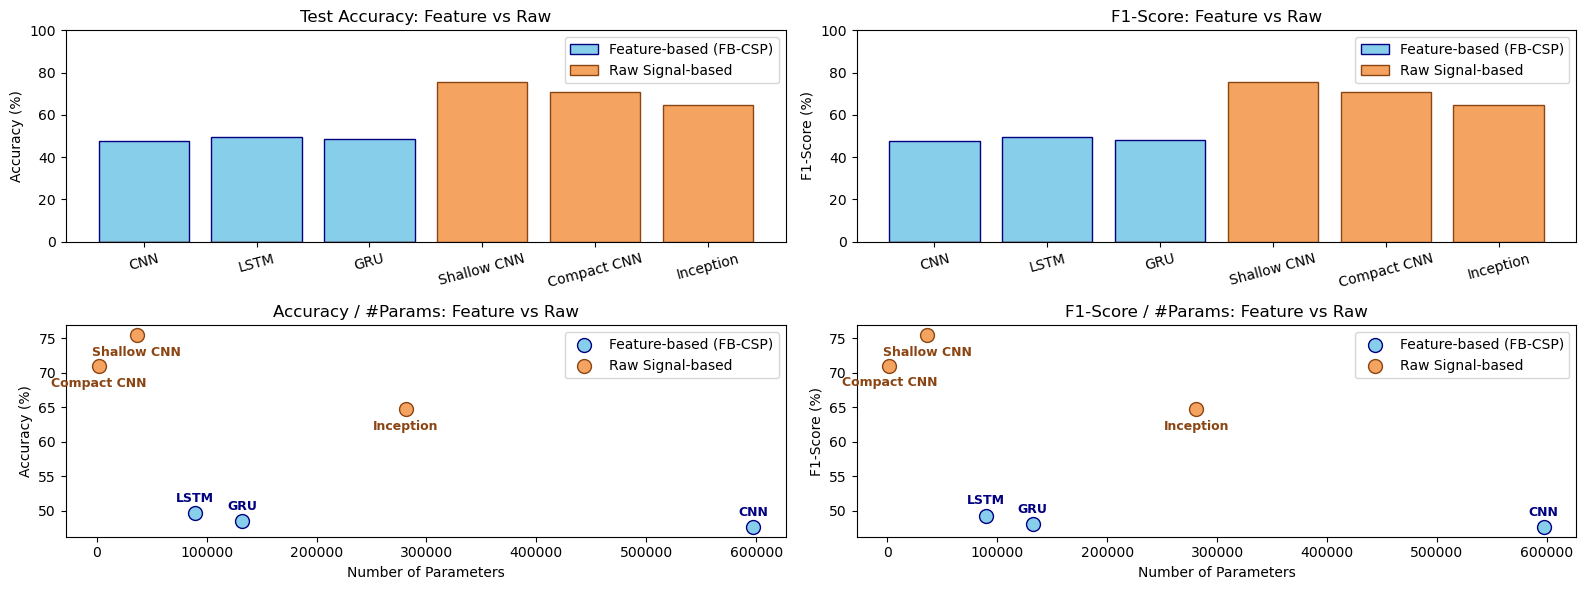

In [60]:
experiments = ['CNN', 'LSTM', 'GRU', 'Shallow CNN', 'Compact CNN',
               'Inception', #'EEGConformer', 'CTNet', 'Dual-Attention-EEGConformer'
            ]
y_true_labels = np.argmax(y_test, axis=1)   



# --- Calculate Metrics ---
# Group 1: Feature-based encoding (CSP)
feat_metrics_acc = [
    accuracy_score(y_true_labels, y_pred_cnn) * 100,
    accuracy_score(y_true_labels, y_pred_lstm) * 100,
    accuracy_score(y_true_labels, y_pred_gru) * 100,
    0, 0, 0 # Placeholders for the raw slots
]

# Group 2: Raw-based encoding
raw_metrics_acc = [
    0, 0, 0, # Placeholders for the feature slots
    accuracy_score(y_true_labels, y_pred_shallow) * 100,
    accuracy_score(y_true_labels, y_pred_eegnet) * 100,
    accuracy_score(y_true_labels, y_pred_inception) * 100,
    #accuracy_score(y_true_labels, y_eegconformer) * 100,
    #accuracy_score(y_true_labels, y_ctnet) * 100,
    #accuracy_score(y_true_labels, y_daec) * 100,
]

# (Repeat same logic for F1)
feat_metrics_f1 = [
    f1_score(y_true_labels, y_pred_cnn, average='weighted') * 100,
    f1_score(y_true_labels, y_pred_lstm, average='weighted') * 100,
    f1_score(y_true_labels, y_pred_gru, average='weighted') * 100,
    0, 0, 0
]
raw_metrics_f1 = [
    0, 0, 0,
    f1_score(y_true_labels, y_pred_shallow, average='weighted') * 100,
    f1_score(y_true_labels, y_pred_eegnet, average='weighted') * 100,
    f1_score(y_true_labels, y_pred_inception, average='weighted') * 100,
    #f1_score(y_true_labels, y_pred_eegconformer, average='weighted') * 100,
    #f1_score(y_true_labels, y_pred_ctnet, average='weighted') * 100,
    #f1_score(y_true_labels, y_pred_daec, average='weighted') * 100,
]

feat_weights = [
    cnn.count_params(),
    lstm.count_params(),
    gru.count_params(),
    0, 0, 0
]
raw_weights = [
    0, 0, 0,
    shallow.count_params(),
    eegnet.count_params(),
    inception.count_params(),
]


# --- Plotting ---
x = np.arange(len(experiments))
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 6))

# Accuracy Plot
ax1.bar(x, feat_metrics_acc, label='Feature-based (FB-CSP)', color='skyblue', edgecolor='navy')
ax1.bar(x, raw_metrics_acc, label='Raw Signal-based', color='sandybrown', edgecolor='saddlebrown')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Test Accuracy: Feature vs Raw')
ax1.set_xticks(x)
ax1.set_xticklabels(experiments, rotation=15)
ax1.set_ylim(0, 100)
ax1.legend()

# F1 Plot
ax2.bar(x, feat_metrics_f1, color='skyblue',label='Feature-based (FB-CSP)', edgecolor='navy')
ax2.bar(x, raw_metrics_f1, color='sandybrown',label='Raw Signal-based', edgecolor='saddlebrown')
ax2.set_ylabel('F1-Score (%)')
ax2.set_title('F1-Score: Feature vs Raw')
ax2.set_xticks(x)
ax2.set_xticklabels(experiments, rotation=15)
ax2.set_ylim(0, 100)
ax2.legend()

# Accuracy Plot
feat_indices = [i for i, w in enumerate(feat_weights) if w > 0]
raw_indices  = [i for i, w in enumerate(raw_weights) if w > 0]
ax3.scatter([feat_weights[i] for i in feat_indices], 
            [feat_metrics_acc[i] for i in feat_indices], 
            label='Feature-based (FB-CSP)', color='skyblue', edgecolor='navy', s=100)

ax3.scatter([raw_weights[i] for i in raw_indices], 
            [raw_metrics_acc[i] for i in raw_indices], 
            label='Raw Signal-based', color='sandybrown', edgecolor='saddlebrown', s=100)
for i in feat_indices:
    ax3.annotate(experiments[i], 
                 (feat_weights[i], feat_metrics_acc[i]),
                 textcoords="offset points", 
                 xytext=(0, 8), 
                 ha='center', fontsize=9, color='navy', fontweight='bold')
for i in raw_indices:
    ax3.annotate(experiments[i], 
                 (raw_weights[i], raw_metrics_acc[i]),
                 textcoords="offset points", 
                 xytext=(0, -15), 
                 ha='center', fontsize=9, color='saddlebrown', fontweight='bold')
ax3.set_ylabel('Accuracy (%)')
ax3.set_xlabel('Number of Parameters')
ax3.set_title('Accuracy / #Params: Feature vs Raw')
ax3.legend()
# F1 Plot
ax4.scatter([feat_weights[i] for i in feat_indices], 
            [feat_metrics_f1[i] for i in feat_indices], 
            label='Feature-based (FB-CSP)', color='skyblue', edgecolor='navy', s=100)

ax4.scatter([raw_weights[i] for i in raw_indices], 
            [raw_metrics_f1[i] for i in raw_indices], 
            label='Raw Signal-based', color='sandybrown', edgecolor='saddlebrown', s=100)
for i in feat_indices:
    ax4.annotate(experiments[i], 
                 (feat_weights[i], feat_metrics_f1[i]),
                 textcoords="offset points", 
                 xytext=(0, 8), 
                 ha='center', fontsize=9, color='navy', fontweight='bold')
for i in raw_indices:
    ax4.annotate(experiments[i], 
                 (raw_weights[i], raw_metrics_f1[i]),
                 textcoords="offset points", 
                 xytext=(0, -15), 
                 ha='center', fontsize=9, color='saddlebrown', fontweight='bold')
ax4.set_ylabel('F1-Score (%)')
ax4.set_xlabel('Number of Parameters')
ax4.set_title('F1-Score / #Params: Feature vs Raw')
ax4.legend()
plt.tight_layout()
plt.show()

## 5. Hyperparameter Optimization

In this section, hyperparameter optimization of the neural networks is explored. Although this is typically implemented with simple methods as out of the box 3-fold cross-validation. However our data is composed of multiple subjects and sessions (usally 2 sessions per subject in BCI competition), then training and testing in subject A will give inflated accuracy (subject leakage) and training and testing on session 1 will make temporal leakage. 

To avoid leakage we must split taking those 2 concepts into account, but also if we want to tune hyperparameters in addition to only evaluation we need to split the data into train/val/test (70/20/10 for example) an perform 2 cross-validations:
- Inner CV: Hyperparameter Tuning (Val data) 
- Outer CV: Evaluation (Test data)

There are 3 strategies we can implement with augmenting levels of complexity: (First one is simple train, test, second allows for evaluation CV, and third one evaluation CV + Hyperparameter optimization CV)

1. **Subject-grouped, session-wise split:**  

   Entire recording sessions for a subject are kept together. Train on one session and test on the other to prevent **temporal/session leakage**.  
    *Example:*  

    | Subject | Train Session | Test Session |
    |---------|---------------|--------------|
    | A       | A1             | A2            |
    | B       | B1             | B2            |
    | C       | C1             | C2            |
    | D       | D1             | D2            |


2. **Leave-One-Subject-Out (LOSO): (Evaluation CV):**
    
    One subject is completely held out for testing, while all other subjects are used for training. This prevents **subject leakage** and provides a realistic estimate of **cross-subject generalization**.  
    *Example:*  

    | Fold | Train Subjects | Test Subject |
    |------------|----------------|--------------|
    | 1          | B, C, D        | A            |
    | 2          | A, C, D        | B            |
    | 3          | A, B, D        | C            |
    | 4          | A, B, C        | D            |


3. **Nested, group-aware cross-validation: (Evaluation CV + HyperparamOPT CV)** 
    
    **Outer CV**: evaluate final model on a held-out subject  **Inner CV**: split sessions within training data for hyperparameter tuning  
    *Example:*  

    | Fold | Outer Test Subject | Inner Train Sessions         | Inner Validation Sessions   |
    |------------|-----------------|------------------------------|----------------------------|
    | 1          | A               | B1, C1, D1                  | B2, C2, D2                 |
    | 2          | B               | A1, C1, D1                  | A2, C2, D2                 |
    | 3          | C               | A1, B1, D1                  | A2, B2, D2                 |
    | 4          | D               | A1, B1, C1                  | A2, B2, C2                 |




--- 
In the case of wanting to use Tree-Parzen or Gaussian Process optimization (Optuna), we could insert it in the Inner CV loop of the nested group aware cross validation, on validation data to prevent test leakeage.

**OBVIOUS NOTE:** Only perform this expensive procedures in promising architectures